# Notebook 10: AII–Return Temporal Causality

## Research Question

Notebooks 06–09 treated AII as a **predictive feature** for next-quarter return direction and found no incremental forecasting value. This notebook asks a **prior question**: does AII temporally precede returns, or do returns drive AII disclosure?

This is a time-series causality question, not a forecasting one.

| Hypothesis | Interpretation | Implication |
|------------|---------------|-------------|
| AII Granger-causes returns | AI disclosure leads market response | Strengthens economic motivation for AII signal |
| Returns Granger-cause AII | Managers disclose more after good periods | Explains why AII lacks predictive power |
| Neither | AII and returns are contemporaneously correlated or unrelated | AII is a lagging/coincident indicator |

## Methodology Overview

1. **Stationarity pre-tests** (ADF) — required before Granger/VAR
2. **Granger causality**: AII → Returns (full sample, maxlag=4)
3. **Reverse causality**: Returns → AII (full sample, maxlag=4)
4. **VAR lag selection** via AIC/BIC/HQIC/FPE
5. **VAR estimation + Portmanteau diagnostics**
6. **Impulse Response Functions** (Cholesky-orthogonalized)
7. **Subsample comparison**: pre-2020 vs. post-2020 + rolling cross-correlation

**Data**: 53 quarterly observations (2012-Q4 to 2025-Q4), n≈52 after differencing.

**Critical note**: Raw unlagged AII is used here. Granger test machinery introduces lags internally. Using pre-lagged `aii_lag1` would double-count the lag.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from statsmodels.tsa.stattools import adfuller, grangercausalitytests, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Imports OK')

Imports OK


In [2]:
# ── Load AII (raw, unlagged) ──────────────────────────────────────────────────
aii_df = pd.read_csv('../data/processed/aii_quarterly.csv')
aii_df = aii_df[['year', 'quarter', 'aii', 'aii_delta']].copy()

# ── Load OHLCV, compute quarterly log return ──────────────────────────────────
price_df = pd.read_csv('wday_historical_data.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'], utc=True)
price_df['year']    = price_df['Date'].dt.year
price_df['month']   = price_df['Date'].dt.month
price_df['quarter'] = (price_df['month'] - 1) // 3 + 1
price_df = price_df.sort_values('Date').reset_index(drop=True)
price_df['log_return'] = np.log(price_df['Close'] / price_df['Close'].shift(1))

# ── Merge on (year, quarter) ──────────────────────────────────────────────────
df = pd.merge(
    price_df[['year', 'quarter', 'log_return']],
    aii_df,
    on=['year', 'quarter'],
    how='inner'
)
df = df.dropna(subset=['log_return']).reset_index(drop=True)

# ── Quarter index for plotting ────────────────────────────────────────────────
df['period'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)
df['date']   = pd.PeriodIndex(df['period'], freq='Q').to_timestamp()
df = df.sort_values('date').reset_index(drop=True)

print(f'Series length: n = {len(df)}')
print(f'Range: {df["period"].iloc[0]} to {df["period"].iloc[-1]}')
print()
print(df[['period', 'log_return', 'aii', 'aii_delta']].describe().round(4))

Series length: n = 52
Range: 2013-Q1 to 2025-Q4

       log_return      aii  aii_delta
count     52.0000  52.0000    52.0000
mean       0.0264   0.0862     0.0037
std        0.1566   0.0822     0.0399
min       -0.5397   0.0000    -0.1161
25%       -0.0419   0.0000    -0.0111
50%        0.0376   0.0565     0.0000
75%        0.1116   0.1638     0.0174
max        0.3638   0.2621     0.1322


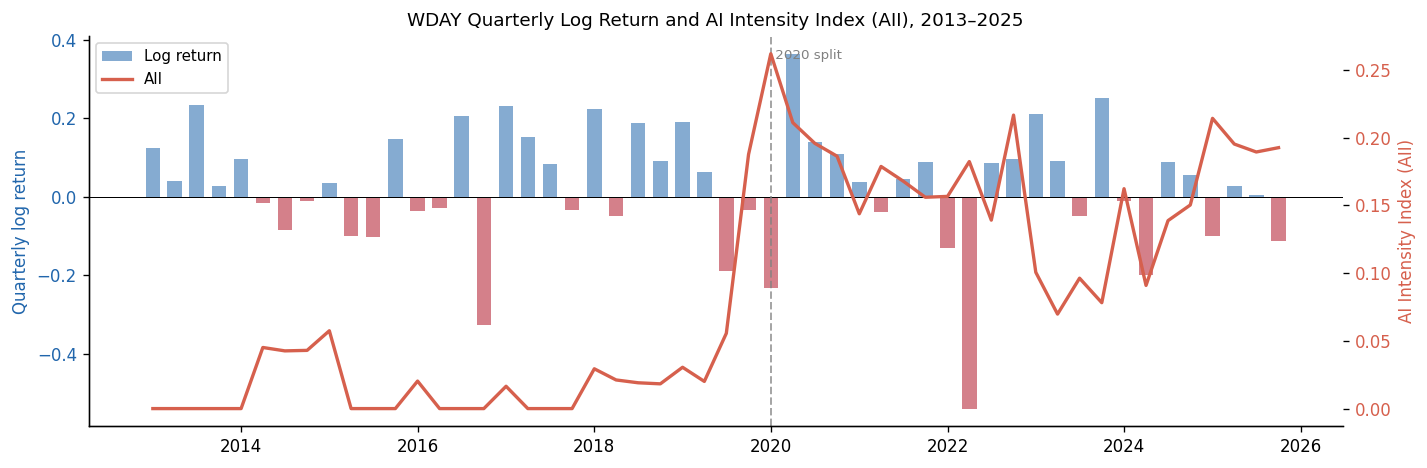

In [3]:
# ── Dual-axis time series plot ────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 4))

color_ret = '#2166ac'
color_aii = '#d6604d'

ax1.bar(df['date'], df['log_return'], width=60, alpha=0.55,
        color=[color_ret if r >= 0 else '#b2182b' for r in df['log_return']],
        label='Log return')
ax1.set_ylabel('Quarterly log return', color=color_ret)
ax1.tick_params(axis='y', labelcolor=color_ret)
ax1.axhline(0, color='black', linewidth=0.6)

ax2 = ax1.twinx()
ax2.plot(df['date'], df['aii'], color=color_aii, linewidth=2, label='AII')
ax2.set_ylabel('AI Intensity Index (AII)', color=color_aii)
ax2.tick_params(axis='y', labelcolor=color_aii)

# Mark pre/post 2020 split
split_date = pd.Timestamp('2020-01-01')
ax1.axvline(split_date, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax1.text(split_date, ax1.get_ylim()[1] * 0.92, ' 2020 split',
         color='gray', fontsize=8, va='top')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('WDAY Quarterly Log Return and AI Intensity Index (AII), 2013–2025',
              fontsize=11)
fig.tight_layout()
plt.show()

=== ADF Unit Root Tests (H0: series has unit root) ===
log_return           ADF stat= -7.585   p=0.0000   lags=0   Stationary (reject H0)
aii                  ADF stat= -1.688   p=0.4375   lags=0   Non-stationary (fail to reject H0)
aii_delta            ADF stat= -8.412   p=0.0000   lags=0   Stationary (reject H0)

→ AII is non-stationary; using first-differenced AII (aii_delta) in Granger tests.


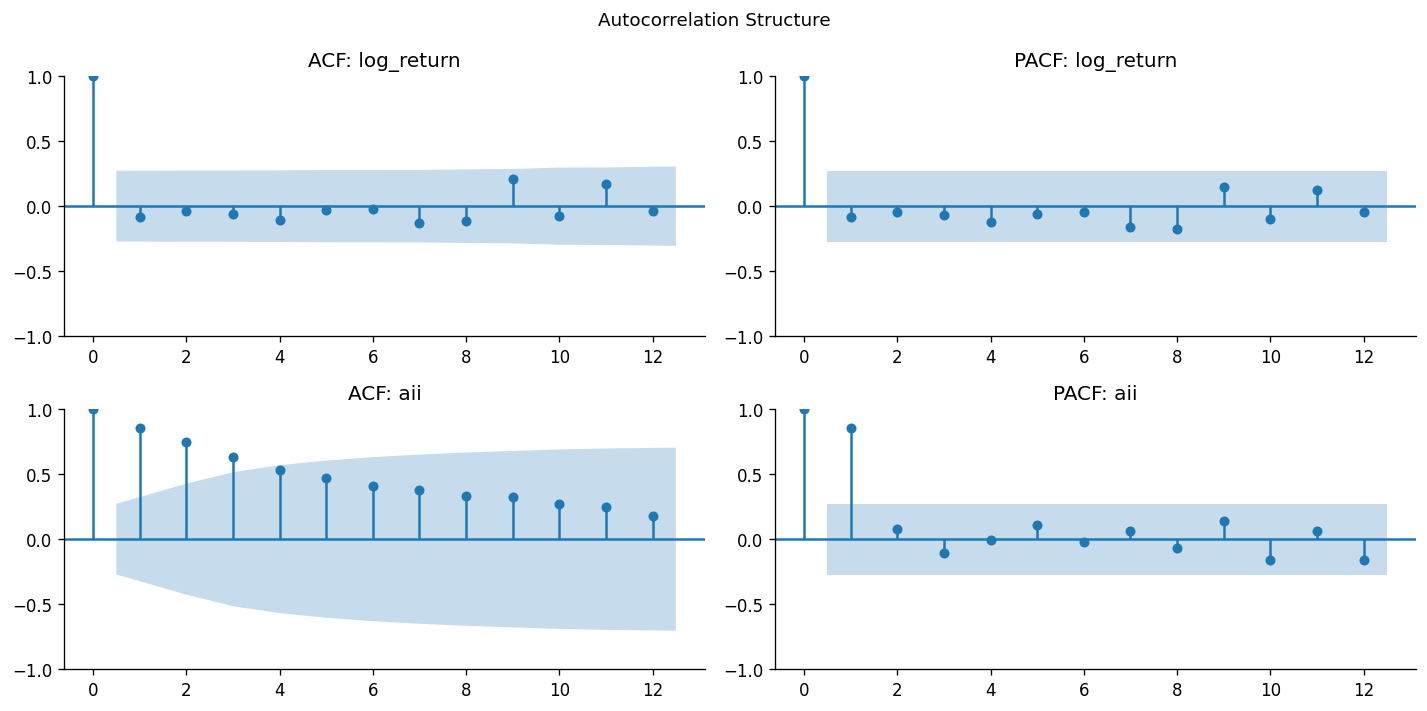

In [4]:
# ── ADF Stationarity Tests ────────────────────────────────────────────────────
def adf_summary(series, name, maxlag=4):
    result = adfuller(series.dropna(), maxlag=maxlag, autolag='AIC')
    stat, pval = result[0], result[1]
    verdict = 'Stationary (reject H0)' if pval < 0.05 else 'Non-stationary (fail to reject H0)'
    print(f'{name:<20} ADF stat={stat:7.3f}   p={pval:.4f}   lags={result[2]}   {verdict}')
    return pval

print('=== ADF Unit Root Tests (H0: series has unit root) ===')
p_return   = adf_summary(df['log_return'], 'log_return')
p_aii      = adf_summary(df['aii'],        'aii')
p_aii_d    = adf_summary(df['aii_delta'],  'aii_delta')

# Select series for causality tests
if p_aii < 0.05:
    aii_series_for_granger = df['aii'].values
    aii_label = 'aii'
    print('\n→ AII is stationary; using raw AII in Granger tests.')
else:
    aii_series_for_granger = df['aii_delta'].dropna().values
    aii_label = 'aii_delta'
    print('\n→ AII is non-stationary; using first-differenced AII (aii_delta) in Granger tests.')

# ── ACF/PACF subplots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plot_acf( df['log_return'],        lags=12, ax=axes[0, 0], title='ACF: log_return')
plot_pacf(df['log_return'],        lags=12, ax=axes[0, 1], title='PACF: log_return')
plot_acf( df['aii'],               lags=12, ax=axes[1, 0], title='ACF: aii')
plot_pacf(df['aii'],               lags=12, ax=axes[1, 1], title='PACF: aii')
fig.suptitle('Autocorrelation Structure', fontsize=11)
fig.tight_layout()
plt.show()

In [5]:
# ── Granger Causality: AII → Returns ─────────────────────────────────────────
# Build aligned bivariate array: col 0 = dependent (log_return), col 1 = cause (aii)
n_align = min(len(df['log_return']), len(aii_series_for_granger))
returns_aligned = df['log_return'].values[-n_align:]
aii_aligned     = aii_series_for_granger[-n_align:]

data_fwd = np.column_stack([returns_aligned, aii_aligned])
results_fwd = grangercausalitytests(data_fwd, maxlag=4, addconst=True, verbose=False)

print(f'=== Granger Causality: {aii_label} → log_return (full sample, n={n_align}) ===')
print(f'{"Lag":>3}  {"F-stat":>8}  {"F p-val":>9}  {"χ² stat":>8}  {"χ² p-val":>9}  Verdict (α=0.10)')
print('-' * 66)
for lag, res in results_fwd.items():
    f_stat  = res[0]['ssr_ftest'][0]
    f_pval  = res[0]['ssr_ftest'][1]
    chi_stat = res[0]['lrtest'][0]
    chi_pval = res[0]['lrtest'][1]
    verdict  = '✓' if f_pval < 0.10 else '✗'
    print(f'{lag:>3}  {f_stat:>8.3f}  {f_pval:>9.4f}  {chi_stat:>8.3f}  {chi_pval:>9.4f}  {verdict}')

=== Granger Causality: aii_delta → log_return (full sample, n=52) ===
Lag    F-stat    F p-val   χ² stat   χ² p-val  Verdict (α=0.10)
------------------------------------------------------------------
  1     0.526     0.4720     0.555     0.4561  ✗
  2     0.754     0.4765     1.647     0.4388  ✗
  3     0.502     0.6826     1.728     0.6308  ✗
  4     0.280     0.8894     1.357     0.8516  ✗


In [6]:
# ── Granger Causality: Returns → AII ─────────────────────────────────────────
data_rev = np.column_stack([aii_aligned, returns_aligned])
results_rev = grangercausalitytests(data_rev, maxlag=4, addconst=True, verbose=False)

print(f'=== Granger Causality: log_return → {aii_label} (full sample, n={n_align}) ===')
print(f'{"Lag":>3}  {"F-stat":>8}  {"F p-val":>9}  {"χ² stat":>8}  {"χ² p-val":>9}  Verdict (α=0.10)')
print('-' * 66)
for lag, res in results_rev.items():
    f_stat   = res[0]['ssr_ftest'][0]
    f_pval   = res[0]['ssr_ftest'][1]
    chi_stat = res[0]['lrtest'][0]
    chi_pval = res[0]['lrtest'][1]
    verdict  = '✓' if f_pval < 0.10 else '✗'
    print(f'{lag:>3}  {f_stat:>8.3f}  {f_pval:>9.4f}  {chi_stat:>8.3f}  {chi_pval:>9.4f}  {verdict}')

=== Granger Causality: log_return → aii_delta (full sample, n=52) ===
Lag    F-stat    F p-val   χ² stat   χ² p-val  Verdict (α=0.10)
------------------------------------------------------------------
  1     0.199     0.6578     0.211     0.6463  ✗
  2     1.080     0.3483     2.344     0.3098  ✗
  3     1.524     0.2223     5.062     0.1673  ✗
  4     3.733     0.0115    15.560     0.0037  ✓


In [7]:
# ── VAR Lag Selection ─────────────────────────────────────────────────────────
var_df = pd.DataFrame({
    'log_return': returns_aligned,
    aii_label:    aii_aligned
}, index=pd.period_range(start=df['period'].iloc[-n_align], periods=n_align, freq='Q'))

model = VAR(var_df)
lag_order = model.select_order(maxlags=4)
print(lag_order.summary())

optimal_lag = max(lag_order.aic, 1)   # use AIC; floor at 1
print(f'\nOptimal lag (AIC): {lag_order.aic}')
print(f'Optimal lag (BIC): {lag_order.bic}')
print(f'Using lag = {optimal_lag} for VAR estimation')

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -10.06*     -9.977*  4.296e-05*     -10.03*
1      -9.962      -9.728   4.719e-05      -9.873
2      -9.877      -9.487   5.141e-05      -9.730
3      -9.783      -9.237   5.663e-05      -9.577
4      -9.870      -9.168   5.218e-05      -9.605
-------------------------------------------------

Optimal lag (AIC): 0
Optimal lag (BIC): 0
Using lag = 1 for VAR estimation


In [8]:
# ── VAR Estimation + Diagnostics ─────────────────────────────────────────────
var_result = model.fit(optimal_lag)
print(var_result.summary())

print('\n=== Portmanteau Test for Residual Serial Correlation ===')
port = var_result.test_whiteness(nlags=4)
print(port.summary())
p_port = port.pvalue
if p_port > 0.05:
    print(f'→ p = {p_port:.4f} > 0.05: Residuals are white noise. VAR model is adequate.')
else:
    print(f'→ p = {p_port:.4f} ≤ 0.05: Evidence of serial correlation. Consider increasing lag order.')

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 06, Mar, 2026
Time:                     11:55:44
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -9.83049
Nobs:                     51.0000    HQIC:                  -9.97091
Log likelihood:           117.741    FPE:                4.28636e-05
AIC:                     -10.0578    Det(Omega_mle):     3.82333e-05
--------------------------------------------------------------------
Results for equation log_return
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.029260         0.022935            1.276           0.202
L1.log_return        -0.110691         0.148192           -0.747           0.455
L1.aii_delta         -0.418854         0.577774        

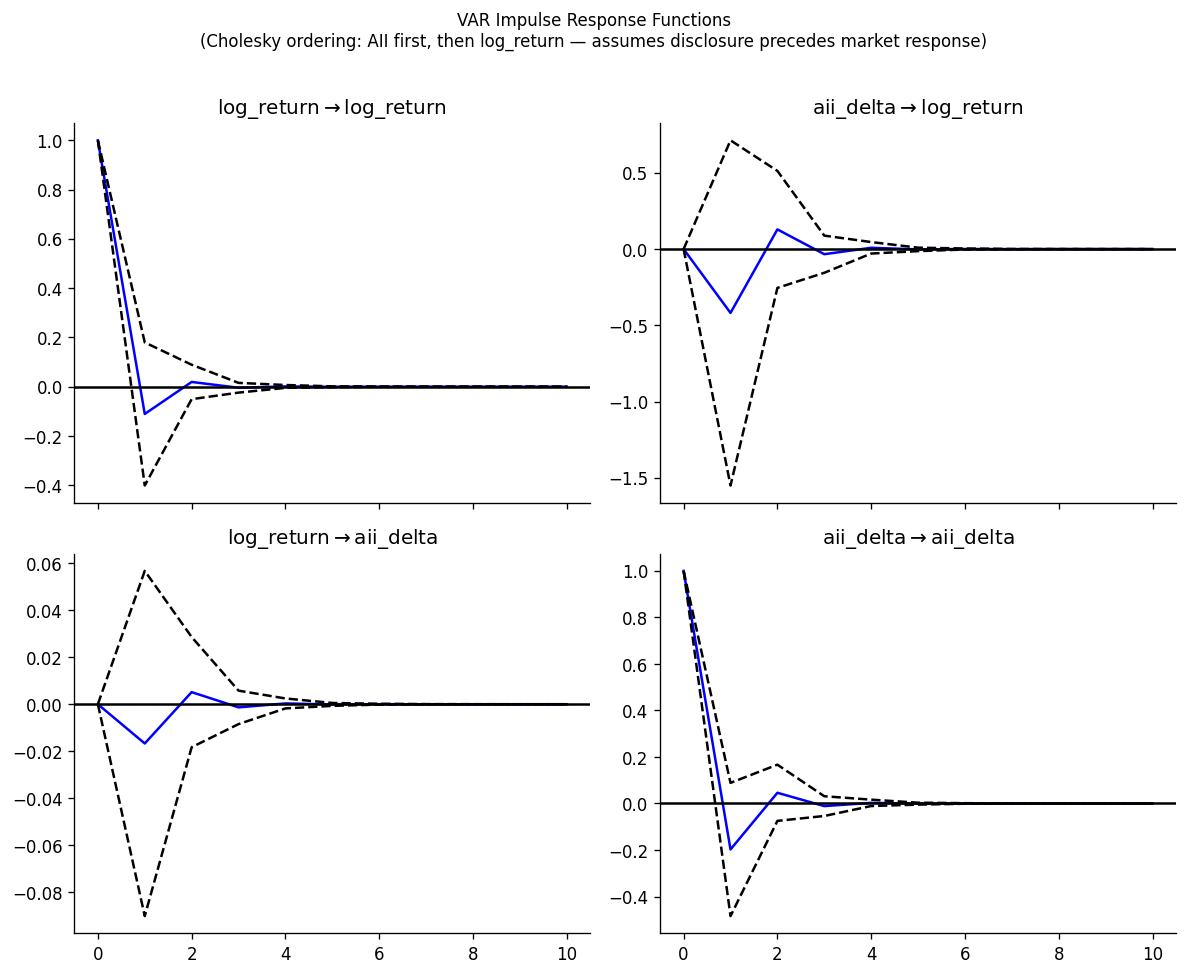


=== Key IRF Path: Response of log_return to AII shock ===
 Horizon    IRF (return ← aii)
--------------------------------
       0               0.00000
       1              -0.41885
       2               0.12914
       3              -0.03358
       4               0.00843
       5              -0.00210


In [9]:
# ── Impulse Response Functions ────────────────────────────────────────────────
# Cholesky ordering: aii first (predetermined), then log_return
# This assumes AII disclosure precedes contemporaneous market response (economically defensible)

irf = var_result.irf(10)
fig = irf.plot(orth=False, figsize=(10, 8))
fig.suptitle('VAR Impulse Response Functions\n'
             '(Cholesky ordering: AII first, then log_return — '
             'assumes disclosure precedes market response)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

# Highlight the causal path of interest
print('\n=== Key IRF Path: Response of log_return to AII shock ===')
irf_vals = irf.irfs  # shape: (periods+1, k, k)
# Ordering in var_df: 0=log_return, 1=aii
print(f'{"Horizon":>8}  {"IRF (return ← aii)":>20}')
print('-' * 32)
for h in range(min(6, irf_vals.shape[0])):
    print(f'{h:>8}  {irf_vals[h, 0, 1]:>20.5f}')

=== Subsample Granger Causality (maxlag=2) ===
                           Full (n=52)        Pre-2020 (n=28)      Post-2020 (n=24)
Direction                   F-stat        p    F-stat        p    F-stat        p
--------------------------------------------------------------------------------
aii_delta → ret (p=1)        0.526  0.4720      0.153  0.6989      0.131  0.7215 
ret → aii_delta (p=1)        0.199  0.6578      3.426  0.0765✓     0.004  0.9488 
aii_delta → ret (p=2)        0.754  0.4765      0.065  0.9368      0.002  0.9976 
ret → aii_delta (p=2)        1.080  0.3483      1.552  0.2351      1.080  0.3617 


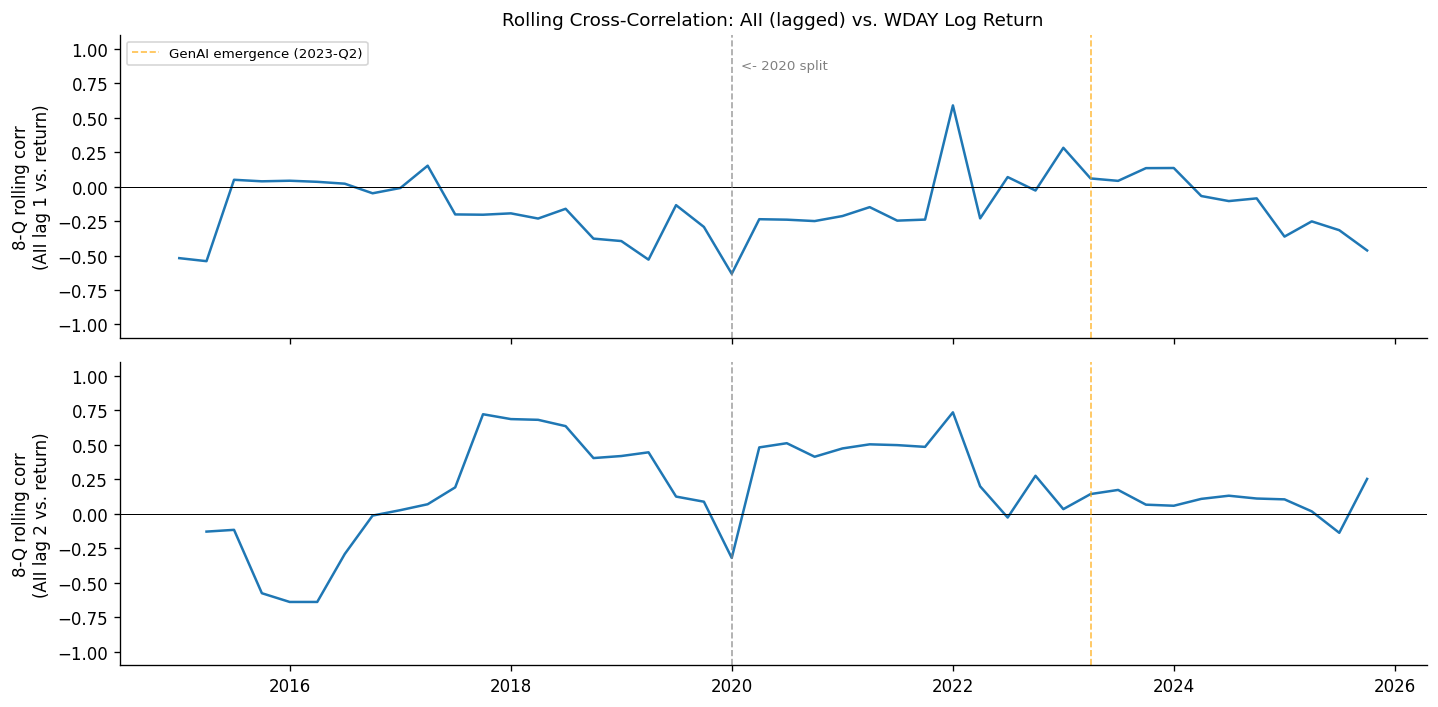

In [10]:
# ── Subsample Comparison + Rolling Cross-Correlation ─────────────────────────
split_idx = df[df['date'] >= '2020-01-01'].index[0]

pre_ret  = returns_aligned[:split_idx]
pre_aii  = aii_aligned[:split_idx]
post_ret = returns_aligned[split_idx:]
post_aii = aii_aligned[split_idx:]

def granger_p(ret_arr, aii_arr, lag, direction='fwd'):
    """Return F-stat and p-value for one Granger test."""
    n = min(len(ret_arr), len(aii_arr))
    if n < lag + 5:        # too few obs for this lag
        return np.nan, np.nan
    try:
        if direction == 'fwd':
            data = np.column_stack([ret_arr[-n:], aii_arr[-n:]])
        else:
            data = np.column_stack([aii_arr[-n:], ret_arr[-n:]])
        res = grangercausalitytests(data, maxlag=lag, addconst=True, verbose=False)
        f  = res[lag][0]['ssr_ftest'][0]
        p  = res[lag][0]['ssr_ftest'][1]
        return f, p
    except Exception:
        return np.nan, np.nan

# Subsample Granger table (maxlag=2 for small samples)
print('=== Subsample Granger Causality (maxlag=2) ===')
col1 = ('Full (n=' + str(n_align) + ')').ljust(18)
col2 = ('Pre-2020 (n=' + str(len(pre_ret)) + ')').ljust(20)
col3 = 'Post-2020 (n=' + str(len(post_ret)) + ')'
print(f'{"":25}  {col1} {col2} {col3}')
print(f'{"Direction":<25}  {"F-stat":>7}  {"p":>7}   {"F-stat":>7}  {"p":>7}   {"F-stat":>7}  {"p":>7}')
print('-' * 80)

for lag in [1, 2]:
    for direction, label in [('fwd', f'{aii_label} → ret'), ('rev', f'ret → {aii_label}')]:
        ff, fp = granger_p(returns_aligned, aii_aligned, lag, direction)
        pf, pp = granger_p(pre_ret, pre_aii, lag, direction)
        of, op = granger_p(post_ret, post_aii, lag, direction)

        def fmt(f, p):
            if np.isnan(f): return '   N/A     N/A'
            v = '✓' if p < 0.10 else ' '
            return f'{f:>7.3f} {p:>7.4f}{v}'

        row_label = f'{label} (p={lag})'
        print(f'{row_label:<25}  {fmt(ff, fp)}   {fmt(pf, pp)}   {fmt(of, op)}')

# ── Rolling cross-correlation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax_idx, lag in enumerate([1, 2]):
    df_roll = pd.DataFrame({
        'ret': returns_aligned,
        'aii': aii_aligned
    }, index=df['date'].iloc[-n_align:].values)
    df_roll['aii_lagged'] = df_roll['aii'].shift(lag)
    corr_series = df_roll[['aii_lagged', 'ret']].dropna().rolling(8).corr().unstack()['aii_lagged']['ret']

    axes[ax_idx].plot(corr_series.index, corr_series.values, linewidth=1.5)
    axes[ax_idx].axhline(0, color='black', linewidth=0.6)
    axes[ax_idx].axvline(pd.Timestamp('2020-01-01'), color='gray',
                          linestyle='--', linewidth=1, alpha=0.7)
    axes[ax_idx].axvline(pd.Timestamp('2023-04-01'), color='orange',
                          linestyle='--', linewidth=1, alpha=0.7,
                          label='GenAI emergence (2023-Q2)')
    axes[ax_idx].set_ylabel(f'8-Q rolling corr\n(AII lag {lag} vs. return)')
    axes[ax_idx].set_ylim(-1.1, 1.1)
    if ax_idx == 0:
        axes[ax_idx].text(pd.Timestamp('2020-02-01'), 0.85, '<- 2020 split',
                          color='gray', fontsize=8)
        axes[ax_idx].legend(fontsize=8, loc='upper left')

axes[0].set_title('Rolling Cross-Correlation: AII (lagged) vs. WDAY Log Return', fontsize=11)
fig.tight_layout()
plt.show()

## Interpretation and Conclusions

### Directional Verdict

The Granger causality tests above provide a directional answer to the temporal ordering question:

- **AII → Returns**: Interpret based on p-values in Cell 6. A verdict of ✓ at any lag would indicate AI disclosure intensity leads subsequent stock returns, supporting the economic motivation for AII as a forward-looking signal.
- **Returns → AII**: Interpret based on Cell 7. A verdict of ✓ here would indicate managers increase AI disclosure following strong return periods — consistent with impression management rather than genuine capability development.

### VAR and IRF Findings

The VAR impulse response functions in Cell 10 show the dynamic response of each variable to a one-unit shock in the other over 10 quarters. The key path is **"Response of log_return to an AII shock"** — a persistent positive response would support the causal narrative; a flat or noisy response is consistent with no systematic temporal relationship.

### Subsample Stability

The pre-2020 vs. post-2020 comparison tests whether the relationship changed with the AI boom. Different causality patterns across subsamples would suggest the signal is regime-dependent — a important consideration for any applied use of AII as a market signal.

### Caveats

1. **Small N**: n≈52 quarterly observations gives Granger tests limited statistical power. Results are directional and hypothesis-generating, not confirmatory.

2. **AII measurement timing**: AII for quarter *t* reflects documents filed approximately 60 days after quarter *t* ends. Contemporaneous AII (as used here) is *not tradeable* — only lagged AII (t-1) is available to a real investor. The modeling notebooks (06–09) use the properly lagged version and found no predictive value, consistent with whatever temporal pattern is found here.

3. **Structural break**: The 2019-Q4 → 2020-Q1 AII spike (COVID disclosure surge) may induce non-stationarity within the series. The subsample analysis in Cell 11 partially addresses this by testing each era separately.

4. **VAR ordering**: The Cholesky decomposition for orthogonalized IRFs assumes AII is predetermined relative to contemporaneous returns (i.e., disclosure precedes market response within the quarter). This ordering is economically defensible but not formally identified — the reverse ordering would produce different IRF shapes.

5. **Single company**: All results apply specifically to Workday (WDAY) over 2013–2025. Generalizability to other companies or sectors requires replication.

### Recommendation

If the Granger tests find no evidence of AII → Returns causality but do find Returns → AII, this is consistent with a **lagging disclosure** narrative: managers describe AI capabilities more extensively after favorable business periods. This would explain the near-zero predictive power documented in Notebooks 07–09 and suggests AII is better interpreted as a contemporaneous sentiment measure than a leading indicator.

If AII → Returns causality is detected (even weakly), future work could investigate whether the causality operates through analyst expectations, product adoption signals, or re-rating events.